In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':14})
import matplotlib.colors as mcolors
from matplotlib.cm import GnBu, viridis

import sys
sys.path.insert(0, '/projects/b1094/jding/athena/vis/python')
import athena_read
import glob


In [15]:
## Snapshots registration
sim_name = 'disk-jiaru6'
#sim_name = 'disk-tilted23b'
#sim_name = 'disk-sph26'
#path = '/scratch/phn2956/disk-sph26/'
path = '/scratch/phn2956/' + sim_name + '/'
snapshot_list = sorted(glob.glob(path+'disk.out1.*.athdf'))


# Plot snapshots over time

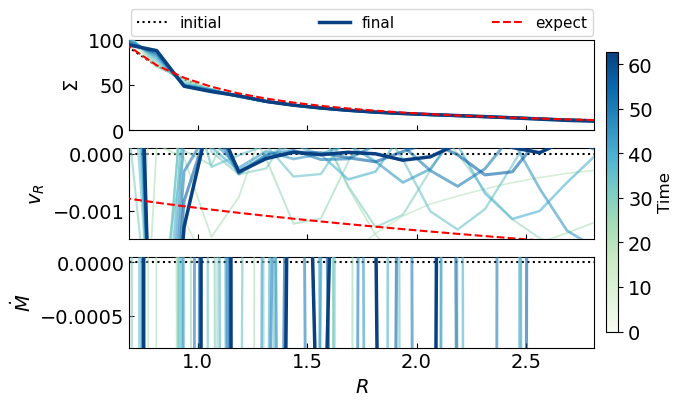

In [17]:
## Plot density, v_r, and Mdot

snapshot_plot = snapshot_list[0:21:2] # snapshot_list[0:101:5]

norm   = mcolors.PowerNorm(gamma=1.5, vmin=0, vmax=len(snapshot_plot)-1)
colors = [GnBu(0.3 + 0.7 * norm(i)) for i in range(len(snapshot_plot))]

fig,axs = plt.subplots(3,1, figsize=(6,4),sharex=True,sharey=False)

for i, frame in enumerate(snapshot_plot):
    
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
    t_sim = ath_data['Time']
    #print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    # ath_data['x1f'] gives the list of cell face coordinates; 'x1v' gives volume-centered values
    rad_app = ath_data['x1f']
    theta_app = ath_data['x2f']
    phi_app = ath_data['x3f']
    d_rad = rad_app[1]-rad_app[0]
    d_theta = theta_app[1]-theta_app[0]
    d_phi = phi_app[1]-phi_app[0]

    # change coordinate system to be based on cells' midpoints
    rad_app = (rad_app[1:]+rad_app[:-1])*0.5
    theta_app = (theta_app[1:]+theta_app[:-1])*0.5
    phi_app = (phi_app[1:]+phi_app[:-1])*0.5
    rad_3d, theta_3d, phi_3d = np.meshgrid(rad_app, theta_app, phi_app, indexing='ij')
    
    #### Read Athena++ data: velocity field. ####    
    vx1 = np.swapaxes(ath_data['vel1'],0,2) # index convention: (r, theta, phi)
    vx2 = np.swapaxes(ath_data['vel2'],0,2)
    vx3 = np.swapaxes(ath_data['vel3'],0,2)
    den = np.swapaxes(ath_data['rho'],0,2)

    ## Sigma = surface integral of rho over a sphere (mass/dr) / (2pi*r)
    Sigma_integrand = den * rad_3d**2 * np.sin(theta_3d) * d_theta * d_phi
    #Sigma = np.sum(Sigma_integrand[:,:,2:-2],axis=(1,2))/(2*np.pi*rad_app)
    Sigma = np.sum(Sigma_integrand[:,2:-2,2:-2],axis=(1,2))/(2*np.pi*rad_app)
    # Sigma = den[:,22,4] # value at midplane at arbitrary phi
    
    ## Mdot = surface integral of rho*vx1 over a sphere (mass/dr)
    Mdot_integrand = den*vx1 *rad_3d**2 * np.sin(theta_3d) * d_theta * d_phi
    #Mdot = np.sum(Mdot_integrand[:,:,2:-2],axis=(1,2))#/(2*np.pi*rad_app)
    Mdot = np.sum(Mdot_integrand[:,2:-2,2:-2],axis=(1,2))#/(2*np.pi*rad_app)

    ## mass-weighted v_R = Mdot / (2pi*r*Sigma)
    vR = Mdot / (Sigma * 2*np.pi*rad_app) 
    # vR = vx1[:,22,4] # value at midplane at arbitrary phi
    
    #### Plot
    
    current_color = colors[i]
    lw     = 1.0 + 1.5 * (i / len(snapshot_plot))
    zorder = i + 10 
    
    if t_sim== 0:
        kws = {'c': 'k', 'ls':':','lw': 1.5, 'label': r'initial' % t_sim, 'zorder': zorder}
    elif i == len(snapshot_plot) - 1:
        kws = {'c': '#084081', 'lw': 2.5, 'label': r'final' % t_sim, 'zorder': zorder + 100}
    else:
        kws = {'c': current_color, 'lw': lw, 'alpha': 0.6, 'zorder': zorder}
        
    axs[0].plot(rad_app,Sigma,**kws)
    axs[1].plot(rad_app,vR,**kws)
    axs[2].plot(rad_app,Mdot,**kws)

    
    
sm = plt.cm.ScalarMappable(cmap=GnBu, norm=plt.Normalize(vmin=0, vmax=t_sim))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Time', fontsize=12)


#### Add analytical solutions
Sigma_sol = Sigma[-1] * (rad_app/rad_app[-1])**-1.5
vR_sol    = vR[-1] * (rad_app/rad_app[-1])**0.5
Mdot_sol  = Mdot[-1] * (rad_app/rad_app[-1])**0
axs[0].plot(rad_app,Sigma_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[1].plot(rad_app,vR_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[2].plot(rad_app,Mdot_sol,c='r',lw=1.5,ls='--',zorder=zorder+200)
axs[0].plot([],[],c='r',lw=1.5,ls='--',zorder=zorder+200,label='expect')

#### labels
axs[0].set_ylabel(r'$\Sigma$')
axs[1].set_ylabel(r'$v_{R}$')
axs[2].set_ylabel(r'$\dot{M}$')
axs[-1].set_xlabel(r'$R$')
axs[-1].set_xlim(rad_app[[3,-4]])

# limits used in disk-sph plots
# axs[0].set_ylim(0, .4)
# axs[1].set_ylim(-1.5e-3, 1e-4)
# axs[2].set_ylim(-8e-4, 5e-5)

# limits used for disk-jiaru plots
axs[0].set_ylim(0, 100) # 1000
axs[1].set_ylim(-1.5e-3, 1e-4)
axs[2].set_ylim(-8e-4, 5e-5)

axs[0].legend(
    fontsize=11,
    loc='lower left',        
    bbox_to_anchor=(0., 1.02, 1., .102), 
    ncol=3,                  
    mode="expand",          
    borderaxespad=0.1       
)


for ax in axs.flatten():
    ax.tick_params(which='both',direction='in')

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-snapshots.png", bbox_inches='tight')


In [7]:
theta_app[-3]

np.float64(1.81455)

## plot $\rho(\vec{r})$

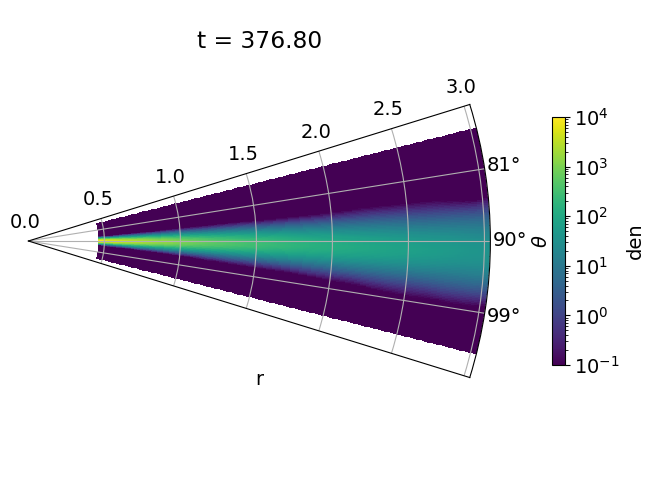

In [13]:
snapshot_plot = snapshot_list[120:121:1] # snapshot_list[0:101:5]

for i, frame in enumerate(snapshot_plot):
    
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
    t_sim = ath_data['Time']
    #print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    rad_app = ath_data['x1f']
    theta_app = ath_data['x2f']
    phi_app = ath_data['x3f']
    d_rad = rad_app[1]-rad_app[0]
    d_theta = theta_app[1]-theta_app[0]
    d_phi = phi_app[1]-phi_app[0]
    
    rad_app = (rad_app[1:]+rad_app[:-1])*0.5
    theta_app = (theta_app[1:]+theta_app[:-1])*0.5
    phi_app = (phi_app[1:]+phi_app[:-1])*0.5
    rad_3d, theta_3d, phi_3d = np.meshgrid(rad_app, theta_app, phi_app, indexing='ij')
    
    #### Read Athena++ data: velosity field. ####    
    vx1 = np.swapaxes(ath_data['vel1'],0,2)
    vx2 = np.swapaxes(ath_data['vel2'],0,2)
    vx3 = np.swapaxes(ath_data['vel3'],0,2)
    den = np.swapaxes(ath_data['rho'],0,2)

    fig = plt.figure(figsize=(8,6))
    #ax = fig.add_subplot()
    ax = fig.add_subplot(projection='polar')
    
    ## view from above
    #theta_ind = 23 # 27 = midplane of domain
    #c = ax.pcolormesh(phi_3d[:, theta_ind, :], rad_3d[:, theta_ind, :], den[:,theta_ind,:], cmap='viridis')
    
    ## view from the side
    phi_offset = 5
    phi_ind = 2 + phi_offset # phi~0
    phi_ind2 = (int) (len(phi_app) / 2) + phi_offset # phi~pi
    
    kws = {'cmap': 'viridis', 'norm': mcolors.LogNorm(vmin=1e-1, vmax=1e4)}
    ax.pcolormesh(theta_3d[:,:,phi_ind], rad_3d[:,:,phi_ind], den[:,:,phi_ind], **kws)
    # for phi \in (pi/2, 3pi/2), theta has to be measured in the opposite direction (so, 2pi-...)
    c = ax.pcolormesh(2*np.pi-theta_3d[:,:,phi_ind2], rad_3d[:,:,phi_ind2], den[:,:,phi_ind2], **kws)
    
    #cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(c, ax=ax, label="den", pad=.1, fraction=0.02)
    
    ## in the below plot, the x-axis points right, the z-axis points up, and the y-axis
    # points into the page/screen
    # ax.set_rlim(.2, 2.2)
    ax.xaxis.set_label_position('top') 
    ax.set_xlabel("r", labelpad=-270)
    
    ax.set_thetalim(np.pi/2- .3, np.pi/2 + .3)
    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)
    ax.set_ylabel(r"$\theta$", labelpad=30)
    ax.yaxis.set_label_position("right")
    #ax.yaxis.tick_right()
    
    plt.title("t = {t_sim:.2f}".format(t_sim=t_sim), y=.9)
    
    save_fig = False
    if save_fig:
        plt.savefig("Figs/" + sim_name + "-rhos/" + "%05d"%i + ".png")

    #plt.close()
    
plt.show()

In [19]:
phi_app

array([-0.9424778 , -0.31415927,  0.31415927,  0.9424778 ,  1.57079633,
        2.19911486,  2.82743339,  3.45575192,  4.08407045,  4.71238898,
        5.34070751,  5.96902604,  6.59734457,  7.2256631 ])

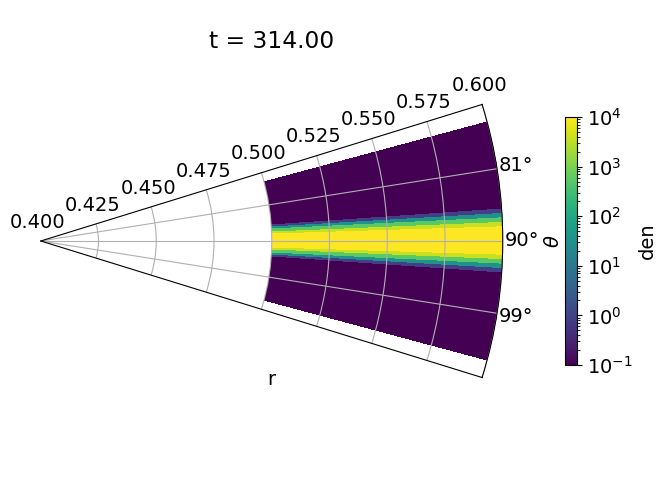

In [24]:
fig = plt.figure(figsize=(8,6))
#ax = fig.add_subplot()
ax = fig.add_subplot(projection='polar')

## view from above
#theta_ind = 23 # 27 = midplane of domain
#c = ax.pcolormesh(phi_3d[:, theta_ind, :], rad_3d[:, theta_ind, :], den[:,theta_ind,:], cmap='viridis')

## view from the side
phi_offset = 0
phi_ind = 2 + phi_offset # phi~0
phi_ind2 = (int) (len(phi_app) / 2) + phi_offset # phi~pi

kws = {'cmap': 'viridis', 'norm': mcolors.LogNorm(vmin=1e-1, vmax=1e4)}
ax.pcolormesh(theta_3d[:,:,phi_ind], rad_3d[:,:,phi_ind], den[:,:,phi_ind], **kws)
# for phi \in (pi/2, 3pi/2), theta has to be measured in the opposite direction (so, 2pi-...)
c = ax.pcolormesh(2*np.pi-theta_3d[:,:,phi_ind2], rad_3d[:,:,phi_ind2], den[:,:,phi_ind2], **kws)

#cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(c, ax=ax, label="den", pad=.1, fraction=0.02)

## in the below plot, the x-axis points right, the z-axis points up, and the y-axis
# points into the page/screen
#ax.set_rlim(.4, 2.1)
ax.set_rlim(.4,.6) 
ax.xaxis.set_label_position('top') 
ax.set_xlabel("r", labelpad=-270)

ax.set_thetalim(np.pi/2- .3, np.pi/2 + .3)
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_ylabel(r"$\theta$", labelpad=30)
ax.yaxis.set_label_position("right")
#ax.yaxis.tick_right()

plt.title("t = {t_sim:.2f}".format(t_sim=t_sim), y=.9)

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-rho.png")

plt.show()

In [28]:
rad_3d[:,0,phi_ind]

array([0.4625, 0.4875, 0.5125, 0.5375, 0.5625, 0.5875, 0.6125, 0.6375,
       0.6625, 0.6875, 0.7125, 0.7375, 0.7625, 0.7875, 0.8125, 0.8375,
       0.8625, 0.8875, 0.9125, 0.9375, 0.9625, 0.9875, 1.0125, 1.0375,
       1.0625, 1.0875, 1.1125, 1.1375, 1.1625, 1.1875, 1.2125, 1.2375,
       1.2625, 1.2875, 1.3125, 1.3375, 1.3625, 1.3875, 1.4125, 1.4375,
       1.4625, 1.4875, 1.5125, 1.5375, 1.5625, 1.5875, 1.6125, 1.6375,
       1.6625, 1.6875, 1.7125, 1.7375, 1.7625, 1.7875, 1.8125, 1.8375,
       1.8625, 1.8875, 1.9125, 1.9375, 1.9625, 1.9875, 2.0125, 2.0375])

In [93]:
hist_path = "/scratch/phn2956/disk-tilted17/disk.hst"
hist = np.loadtxt(hist_path)

In [99]:
hist[:,]

np.float64(0.0)

## plot $v_i(\vec{r})$

In [61]:
vx1[:,-1,phi_ind]

array([-0.37512565, -0.38512139, -0.39486461, -0.25506534, -0.18832564,
       -0.12257466, -0.10200738, -0.10212605, -0.10358885, -0.10456229,
       -0.10437881, -0.10304118, -0.10104618, -0.09893228, -0.09723414,
       -0.09621158, -0.09576739, -0.09556113, -0.09529648, -0.09466174,
       -0.0934724 , -0.09171316, -0.08950093, -0.08699843, -0.08435512,
       -0.08168196, -0.07904816, -0.07649627, -0.07405069, -0.07171989,
       -0.06950698, -0.06740516, -0.06539418, -0.06345537, -0.06157593,
       -0.05974545, -0.05795569, -0.05620005, -0.05447756, -0.05279133,
       -0.05114359, -0.04953768, -0.04797778, -0.04646744, -0.04500539,
       -0.04358742, -0.04220739, -0.04085287, -0.03950159, -0.03811966,
       -0.03666258, -0.03508699, -0.03334727, -0.03141222, -0.02928096,
       -0.02698888, -0.02460353, -0.02221446, -0.0199185 , -0.0178254 ,
       -0.01610127, -0.01507556, -0.01517007, -0.015264  ])

In [44]:
np.max(np.abs(vx3[:,:,phi_ind]))

np.float64(1.5911611582707663)

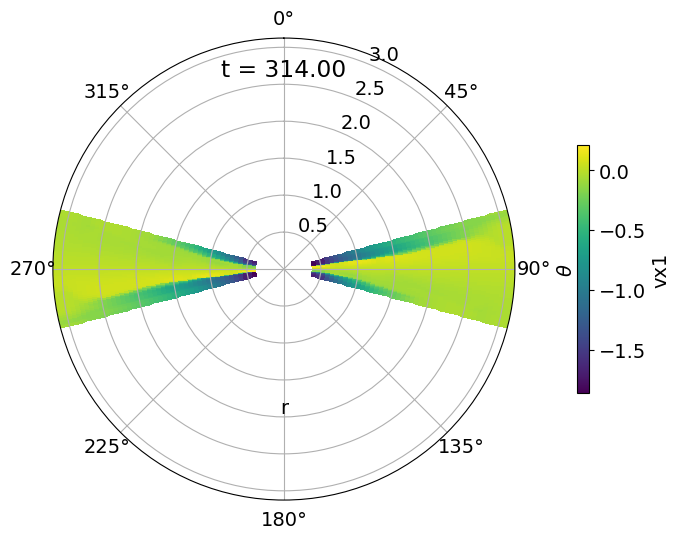

In [34]:
fig = plt.figure(figsize=(8,6))
#ax = fig.add_subplot()
ax = fig.add_subplot(projection='polar')

## view from the side
phi_ind_offset = 0
phi_ind = 2 + phi_ind_offset # phi~0
phi_ind2 = (int) (len(phi_app) / 2) + phi_ind_offset # phi~pi

kws = {'cmap': 'viridis'}#, 'norm': mcolors.LogNorm(vmin=1e-2, vmax=10)}
ax.pcolormesh(theta_3d[:,:,phi_ind], rad_3d[:,:,phi_ind], vx1[:,:,phi_ind], **kws)
# for phi \in (pi/2, 3pi/2), theta has to be measured in the opposite direction (so, 2pi-...)
c = ax.pcolormesh(2*np.pi-theta_3d[:,:,phi_ind2], rad_3d[:,:,phi_ind2], vx1[:,:,phi_ind2], **kws)

#cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(c, ax=ax, label="vx1", pad=.1, fraction=0.02)

## in the below plot, the x-axis points right, the z-axis points up, and the y-axis
# points into the page/screen
#ax.set_rlim(.45,.55)
#ax.set_rlim(.4, 2.1)
ax.xaxis.set_label_position('top') 
ax.set_xlabel("r", labelpad=-270)

#ax.set_thetalim(np.pi/2- .35, np.pi/2 + .35)
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_ylabel(r"$\theta$", labelpad=30)
ax.yaxis.set_label_position("right")
#ax.yaxis.tick_right()

plt.title("t = {t_sim:.2f}".format(t_sim=t_sim), y=.9)

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-vx1.png")

plt.show()

## print slopes of profiles

The slopes should be $\Sigma \propto R^{-1.5}, v_R \propto R^{0.5},$ and $\dot{M} \propto R^{0}$.

In [25]:
# indices of the two points we use to find the slope
i1 = 9
i2 = 17

slope = (np.log(Sigma[i2]) - np.log(Sigma[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("Sigma slope=", np.round(slope,3))

vR_abs = np.abs(vR)
slope = (np.log(vR_abs[i2]) - np.log(vR_abs[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("vR slope=", np.round(slope,3))

Mdot_abs = np.abs(Mdot)
slope = (np.log(Mdot_abs[i2]) - np.log(Mdot_abs[i1])) / \
    (np.log(rad_app[i2]) - np.log(rad_app[i1]))
print("Mdot slope=", np.round(slope,3))

Sigma slope= -1.492
vR slope= 0.56
Mdot slope= 0.068


# plot $\beta(R)$

Given the total angular momentum vector $\vec{L}(R)$, the inclination $\beta$ is defined via $\hat{L} = \langle \cos \gamma \sin \beta, \sin \gamma \sin \beta, \cos \beta \rangle$. Here, I calculate $\beta$ by taking the inverse cosine of the z-component of $\hat{L}$.

In [7]:
## helper functions
def SphToCart(r, theta, phi):
    '''
    Given spherical coordinates r, theta, and phi, return the Cartesian
    coordinates x, y, and z.
    
    '''

    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)

    return x, y, z

def VelSphToCart(theta, phi, vr, vtheta, vphi):
    '''
    Given spherical coordinates (theta,phi) and the velocity components
    in spherical coordinates, return the velocity components in 
    Cartesian coordinates.

    '''

    rHat = [np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)]
    thetaHat = [np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)]
    phiHat = [-np.sin(phi), np.cos(phi), 0]

    vx = vr*rHat[0] + vtheta*thetaHat[0] + vphi*phiHat[0]
    vy = vr*rHat[1] + vtheta*thetaHat[1] + vphi*phiHat[1]
    vz = vr*rHat[2] + vtheta*thetaHat[2] + vphi*phiHat[2]

    return vx, vy, vz

In [8]:
def calculateBetaR(rs, thetas, phis, dens, vrs, vthetas, vphis):
    '''
    Given the 3D coordinate grids (rs, thetas, phis), the 3D density data array,
    and the (spherical) velocity component data arrays, return beta(R).
    
    '''

    # assumes uniformaly spaced grid
    dr = rs[1,0,0] - rs[0,0,0]
    dtheta = thetas[0,1,0] - thetas[0,0,0]
    dphi = phis[0,0,1] - phis[0,0,0]

    # Cartesian coordinates
    xs, ys, zs = SphToCart(rs, thetas, phis)
    vxs, vys, vzs = VelSphToCart(thetas, phis, vrs, vthetas, vphis)
    
    dVs = rs*rs * np.sin(thetas) * dr * dtheta * dphi
    Lxs = dens*dVs * (ys*vzs - zs*vys)
    Lys = dens*dVs * (zs*vxs - xs*vzs)
    Lzs = dens*dVs * (xs*vys - ys*vxs)

    # integrate over theta,phi
    Lx_R = np.sum(Lxs[:,2:-2,2:-2],axis=(1,2))
    Ly_R = np.sum(Lys[:,2:-2,2:-2],axis=(1,2))
    Lz_R = np.sum(Lzs[:,2:-2,2:-2],axis=(1,2))

    Lz_hats = Lz_R / np.sqrt(Lx_R*Lx_R + Ly_R*Ly_R + Lz_R*Lz_R)

    #print("Lz_hats:", Lz_hats)
    return np.arccos(Lz_hats)

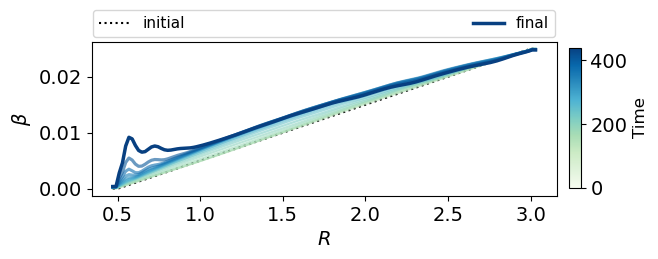

In [9]:
## Plot density, v_r, and Mdot

snapshot_plot = snapshot_list[0:201:10] # snapshot_list[0:101:5]

norm   = mcolors.PowerNorm(gamma=1.5, vmin=0, vmax=len(snapshot_plot)-1)
colors = [GnBu(0.3 + 0.7 * norm(i)) for i in range(len(snapshot_plot))]

fig,axs = plt.subplots(1,1, figsize=(6,2),sharex=True,sharey=False)

for i, frame in enumerate(snapshot_plot):
    
    ath_data  = athena_read.athdf(frame,num_ghost=2,quantities=["rho", "vel1", "vel2", "vel3"])
    t_sim = ath_data['Time']
    #print('loading snapshot at t= %5.1f'%t_sim)
    
    #### Read Athena++ data: coordinates. ####
    rad_app = ath_data['x1f']
    theta_app = ath_data['x2f']
    phi_app = ath_data['x3f']
    # d_rad = rad_app[1]-rad_app[0]
    # d_theta = theta_app[1]-theta_app[0]
    # d_phi = phi_app[1]-phi_app[0]
    
    rad_app = (rad_app[1:]+rad_app[:-1])*0.5
    theta_app = (theta_app[1:]+theta_app[:-1])*0.5
    phi_app = (phi_app[1:]+phi_app[:-1])*0.5
    rad_3d, theta_3d, phi_3d = np.meshgrid(rad_app, theta_app, phi_app, indexing='ij')
    
    #### Read Athena++ data: velocity field. ####    
    vx1 = np.swapaxes(ath_data['vel1'],0,2) # index convention: (r, theta, phi)
    vx2 = np.swapaxes(ath_data['vel2'],0,2)
    vx3 = np.swapaxes(ath_data['vel3'],0,2)
    den = np.swapaxes(ath_data['rho'],0,2)

    betas = calculateBetaR(rad_3d, theta_3d, phi_3d, den, vx1, vx2, vx3)
    
    #### Plot
    
    current_color = colors[i]
    lw     = 1.0 + 1.5 * (i / len(snapshot_plot))
    zorder = i + 10 
    
    if t_sim== 0:
        kws = {'c': 'k', 'ls':':','lw': 1.5, 'label': r'initial' % t_sim, 'zorder': zorder}
    elif i == len(snapshot_plot) - 1:
        kws = {'c': '#084081', 'lw': 2.5, 'label': r'final' % t_sim, 'zorder': zorder + 100}
    else:
        kws = {'c': current_color, 'lw': lw, 'alpha': 0.6, 'zorder': zorder}
        
    axs.plot(rad_app,betas,**kws)
    
sm = plt.cm.ScalarMappable(cmap=GnBu, norm=plt.Normalize(vmin=0, vmax=t_sim))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Time', fontsize=12)

#### labels
axs.set_ylabel(r'$\beta$')
axs.set_xlabel(r'$R$')
#axs.set_xlim(rad_app[[3,-4]])

# limits used in disk-sph plots
#axs[0].set_ylim(0, .4)
#axs[1].set_ylim(-1.5e-3, 1e-4)
#axs[2].set_ylim(-8e-4, 5e-5)

# limits used for disk-jiaru plots
#axs[0].set_ylim(0, 100) # 1000
#axs[1].set_ylim(-1.5e-3, 1e-4)
#axs[2].set_ylim(-8e-4, 5e-5)

axs.legend(
    fontsize=11,
    loc='lower left',        
    bbox_to_anchor=(0., 1.02, 1., .102), 
    ncol=3,                  
    mode="expand",          
    borderaxespad=0.1       
)


# for ax in axs.flatten():
#     ax.tick_params(which='both',direction='in')

save_fig = False
if save_fig:
    plt.savefig("Figs/" + sim_name + "-beta.png", bbox_inches='tight')
